# Base Inference Comparison — No Fine-Tuning
## Machathon Table Extraction Challenge · Phase 1 Dataset

This notebook benchmarks **five pre-trained table detection / structure recognition models** on the same data, evaluating them against the full 6-category COCO annotation set **without any fine-tuning**.

| # | Model | Backbone | Library |
|---|-------|----------|---------|
| 1 | **TATR-ResNet50** | ResNet-50 | Hugging Face `transformers` |
| 2 | **TATR + Swin-T** | Swin-Tiny | Hugging Face `transformers` |
| 3 | **SLANet-1M** | Lightweight CNN | `paddleocr` PP-StructureV2 |
| 4 | **RT-DETR-L** | ResNet-DETR-Large | `ultralytics` |
| 5 | **VAST** | DETR-based | `gmft` |

**Dataset categories evaluated:**

| ID | Name | Count |
|----|------|-------|
| 1 | table | 1 791 |
| 2 | table column | 8 274 |
| 3 | table row | 20 558 |
| 4 | table column header | 1 453 |
| 5 | table projected row header | 1 207 |
| 6 | table spanning cell | 3 567 |

## Section 1 — Install Dependencies

In [ ]:
# ## Section 1 — Install Dependencies (Python 3.12 Safe Version)

# We use a standard cell command to avoid subprocess logic issues
# This script installs what works on 3.12 and skips what doesn't.

print("Updating core installer tools...")
!pip install --upgrade pip setuptools wheel --quiet

def safe_install(name, install_cmd):
    try:
        print(f"Installing {name}...")
        import subprocess
        subprocess.check_call(install_cmd, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
        print(f"  ✅ {name} installed.")
    except Exception:
        print(f"  ❌ {name} failed to install (Likely incompatible with Python 3.12). Skipping.")

# 1. Essential libraries (Work on 3.12)
!pip install pycocotools opencv-python-headless Pillow numpy pandas matplotlib seaborn tqdm --quiet

# 2. Deep Learning Frameworks
!pip install torch torchvision timm ultralytics transformers gmft --quiet
print("  ✅ Torch, Transformers, Ultralytics, and GMFT installed.")

# 3. PaddleOCR (SLANet) - Problematic on 3.12
safe_install("Paddle", "pip install paddlepaddle")
safe_install("PaddleOCR", "pip install paddleocr")

print("\n--- Installation Summary ---")
print("Standard models (TATR-ResNet50, TATR-Swin-T, RT-DETR-L, VAST) are READY.")
print("If Paddle failed above, SLANet benchmark will be skipped automatically in Section 8.")

Updating core installer tools...
  ✅ Torch, Transformers, and Ultralytics installed.
Installing MMEngine...
  ✅ MMEngine installed.
Installing MMCV...
  ❌ MMCV failed to install (Likely incompatible with Python 3.12). Skipping.
Installing MMDet...
  ✅ MMDet installed.
Installing Paddle...
  ✅ Paddle installed.
Installing PaddleOCR...
  ✅ PaddleOCR installed.

--- Installation Summary ---
Standard models (TATR-ResNet50, RT-DETR-L) are READY.
If MMCV/Paddle failed above, those specific benchmarks will be skipped automatically in Section 7/8.


In [3]:
# Fix for common PaddleOCR issues on Python 3.12
!pip install pyclipper lanms-neo --quiet

In [4]:
!pip install --upgrade tqdm --quiet

In [5]:
# Run this to fix the PaddleOCR / LangChain conflict
!pip install langchain langchain-community --quiet

In [6]:
import sys
from types import ModuleType

# Create dummy modules for things PaddleOCR is failing to find on Python 3.12
def mock_missing_module(name):
    if name not in sys.modules:
        m = ModuleType(name)
        sys.modules[name] = m
        return m
    return sys.modules[name]

# Mock LangChain components to bypass PaddleOCR's dependency check
lc = mock_missing_module("langchain")
lc_ds = mock_missing_module("langchain.docstore")
lc_ds_doc = mock_missing_module("langchain.docstore.document")
lc_ds_doc.Document = type("Document", (), {}) # Add a dummy Document class

print("✅ PaddleOCR dependencies mocked. You can now run Section 2.")

✅ PaddleOCR dependencies mocked. You can now run Section 2.


In [7]:
import sys
from types import ModuleType

# 1. Force Reset the PaddleX Global State (to avoid RuntimeError)
if 'paddlex' in sys.modules:
    try:
        import paddlex
        paddlex.repo_manager.core._GlobalContext._initialized = False
        print("✅ PaddleX state reset.")
    except:
        pass

# 2. Clean up any existing broken langchain mocks
for key in list(sys.modules.keys()):
    if key.startswith('langchain'):
        del sys.modules[key]

# 3. Create a Package Mock (the __path__ attribute is the key!)
def create_package_mock(name):
    mock = ModuleType(name)
    mock.__path__ = [] # This tells Python "I am a package, you can look inside me"
    sys.modules[name] = mock
    return mock

# Mock the main packages
lc = create_package_mock("langchain")
lcc = create_package_mock("langchain_community")

# Mock the submodules PaddleX is looking for
submodules = [
    "langchain.docstore",
    "langchain.docstore.document",
    "langchain.text_splitter",
    "langchain_community.vectorstores"
]

for sm in submodules:
    m = ModuleType(sm)
    if sm == "langchain.text_splitter":
        # Add the specific class PaddleX wants to import
        m.RecursiveCharacterTextSplitter = type("RecursiveCharacterTextSplitter", (), {})
    if sm == "langchain.docstore.document":
        # Add the specific class PaddleX wants to import
        m.Document = type("Document", (), {})
    
    sys.modules[sm] = m

print("✅ LangChain mocked as a package. Now run Section 2 (Imports).")

✅ LangChain mocked as a package. Now run Section 2 (Imports).


In [8]:
import sys
from unittest.mock import MagicMock

# 1. Reset the stuck PaddleX initialization flag (to avoid RuntimeError)
if 'paddlex' in sys.modules:
    try:
        import paddlex
        paddlex.repo_manager.core._GlobalContext._initialized = False
    except:
        pass

# 2. INTERCEPT: Create a fake dependency checker
# This makes PaddleX believe that LangChain is NOT installed, 
# even if there are broken files on the disk.
deps_mock = MagicMock()
deps_mock.is_dep_available.return_value = False

# Inject this mock into the system before PaddleOCR can load its own
sys.modules["paddlex.utils.deps"] = deps_mock
sys.modules["paddlex.inference.pipelines.components.utils.deps"] = deps_mock

# 3. BLACKLIST: Ensure langchain is treated as missing
sys.modules["langchain"] = None
sys.modules["langchain_community"] = None

print("✅ PaddleX dependency checker has been intercepted.")
print("✅ PaddleOCR will now believe LangChain is missing and skip the broken imports.")
print("✅ You can now run Section 2 (Imports).")

✅ PaddleX dependency checker has been intercepted.
✅ PaddleOCR will now believe LangChain is missing and skip the broken imports.
✅ You can now run Section 2 (Imports).


In [10]:
import sys
# Clear all paddle and langchain related modules from memory
for key in list(sys.modules.keys()):
    if 'paddle' in key or 'paddlex' in key or 'langchain' in key:
        del sys.modules[key]
print("✅ Memory cleaned. The corrupted state is gone.")

✅ Memory cleaned. The corrupted state is gone.


## Section 2 — Import Libraries & Configure Paths

In [ ]:
import os
import json
import warnings
import pandas as pd
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torchvision.transforms as T
from PIL import Image
from collections import defaultdict
from IPython.display import display

# Core libraries
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from transformers import TableTransformerForObjectDetection, AutoImageProcessor
from ultralytics import RTDETR

# ─────────────────────────────────────────────────────────────────────────────
# PADDLEOCR FIX: Import PPStructure directly from the source file
# This bypasses the broken __init__.py logic and the LangChain errors
# ─────────────────────────────────────────────────────────────────────────────
try:
    from paddleocr import PPStructure
    print("✅ PPStructure loaded successfully.")
except Exception as e:
    print(f"⚠️ PaddleOCR could not be loaded: {e}")
    PPStructure = None 

# ─────────────────────────────────────────────────────────────────────────────
# SETTINGS & PATHS
# ─────────────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ANNOTATIONS_PATH = "/kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/annotations/Cells_Anotations_coco.json"
IMAGES_DIR = "/kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/images"

CATEGORY_ID_TO_NAME = {1: "table", 2: "table column", 3: "table row", 4: "table column header", 5: "table projected row header", 6: "table spanning cell"}
CATEGORY_NAME_TO_ID = {v: k for k, v in CATEGORY_ID_TO_NAME.items()}
CONFIDENCE_THRESH = 0.50
MODEL_NAMES = ["TATR-ResNet50", "TATR+Swin-T", "SLANet-1M", "RT-DETR-L", "VAST"]
MODEL_COLORS = {"TATR-ResNet50": "#E74C3C", "TATR+Swin-T": "#3498DB", "SLANet-1M": "#2ECC71", "RT-DETR-L": "#F39C12", "VAST": "#9B59B6"}
RANDOM_SEED = 42
N_SAMPLE_IMAGES = 3

print(f"Setup Complete. Device: {DEVICE}")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


⚠️ PaddleOCR could not be loaded: PDX has already been initialized. Reinitialization is not supported.
Setup Complete. Device: cuda


## Section 3 — Load & Parse COCO Annotations

In [12]:
# ─────────────────────────────────────────────
# Load via pycocotools COCO API
# ─────────────────────────────────────────────
coco_gt_api = COCO(ANNOTATIONS_PATH)

# Raw JSON for direct access
with open(ANNOTATIONS_PATH, "r") as fh:
    raw_coco = json.load(fh)

# ── Images ────────────────────────────────────
df_images = pd.DataFrame(raw_coco["images"]).rename(columns={"id": "image_id"})
print(f"Total images : {len(df_images):,}")

# ── Annotations ───────────────────────────────
df_anns = pd.DataFrame(raw_coco["annotations"])
df_anns["bbox_x"] = df_anns["bbox"].apply(lambda b: b[0])
df_anns["bbox_y"] = df_anns["bbox"].apply(lambda b: b[1])
df_anns["bbox_w"] = df_anns["bbox"].apply(lambda b: b[2])
df_anns["bbox_h"] = df_anns["bbox"].apply(lambda b: b[3])
df_anns = df_anns.merge(
    df_images[["image_id", "file_name", "width", "height"]],
    on="image_id", how="left"
)
df_anns["category_name"] = df_anns["category_id"].map(CATEGORY_ID_TO_NAME)
print(f"Total annotations: {len(df_anns):,}")

# ── Per-category breakdown ─────────────────────
print("\nAnnotations per category:")
for cat_id, cat_name in CATEGORY_ID_TO_NAME.items():
    n = (df_anns["category_id"] == cat_id).sum()
    print(f"   [{cat_id}] {cat_name:<35s}: {n:,}")

# ── image_id → annotations lookup ─────────────
ann_by_image: dict[int, list[dict]] = defaultdict(list)
for rec in raw_coco["annotations"]:
    ann_by_image[rec["image_id"]].append(rec)

print("\nCOCO dataset loaded successfully.")


loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
Total images : 1,500
Total annotations: 36,850

Annotations per category:
   [1] table                              : 1,791
   [2] table column                       : 8,274
   [3] table row                          : 20,558
   [4] table column header                : 1,453
   [5] table projected row header         : 1,207
   [6] table spanning cell                : 3,567

COCO dataset loaded successfully.


## Section 4 — Filter Valid Samples

**Rule (from project notes):**  
Some images only contain sub-structure annotations (categories 2–6) *without* a parent `table` (category 1) label.  
These images are **skipped** — we require at least one `table` bounding box to serve as the detection target for base-inference models.  
The categories themselves (2–6) are still evaluated; only imageswithout category-1 labels are excluded.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Build set of image_ids that contain at least one 'table' (cat_id == 1)
# ─────────────────────────────────────────────────────────────────────────────
images_with_table = set(
    df_anns.loc[df_anns["category_id"] == 1, "image_id"].unique()
)

# Further require that the image file exists on disk
valid_records = []
missing_files = 0

for _, row in df_images.iterrows():
    img_id   = row["image_id"]
    filename = row["file_name"]
    img_path = os.path.join(IMAGES_DIR, filename)

    if img_id not in images_with_table:
        continue                   # skip: no 'table' ground-truth label

    if not os.path.isfile(img_path):
        missing_files += 1
        continue                   # skip: image file absent from disk

    valid_records.append({
        "image_id": img_id,
        "file_name": filename,
        "img_path": img_path,
        "width": row["width"],
        "height": row["height"],
    })

df_valid = pd.DataFrame(valid_records)

n_total   = len(df_images)
n_valid   = len(df_valid)
n_skipped = n_total - n_valid - missing_files

print(f"Total images          : {n_total:,}")
print(f"Retained (valid)      : {n_valid:,}")
print(f"Skipped (no cat-1 GT) : {n_skipped:,}")
print(f"Skipped (file missing): {missing_files:,}")
print(f"\nValid image IDs sample : {df_valid['image_id'].head(5).tolist()}")


Total images          : 1,500
Retained (valid)      : 1,500
Skipped (no cat-1 GT) : 0
Skipped (file missing): 0

Valid image IDs sample : [1, 2, 3, 4, 5]


## Section 5 — Preprocessing Pipeline

Applies the same normalisation used in `Phase2_Preprocessing_Data_Engineering.ipynb`:  
- Load with PIL → convert to RGB  
- Resize to **800 × 800**  
- Normalise with ImageNet statistics `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`  

Also defines shared utility functions used across all inference sections.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared preprocessing (mirrors Phase2_Preprocessing_Data_Engineering.ipynb)
# ─────────────────────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
RESIZE_DIM    = 800

_shared_transform = T.Compose([
    T.Resize((RESIZE_DIM, RESIZE_DIM)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def preprocess_image(img_path: str):
    """
    Load an image and return:
        pil_img  : original PIL.Image (RGB, original resolution)
        tensor   : normalised float tensor of shape (1, 3, 800, 800)
        orig_hw  : (height, width) of the *original* image
    """
    pil_img  = Image.open(img_path).convert("RGB")
    orig_hw  = (pil_img.height, pil_img.width)
    tensor   = _shared_transform(pil_img).unsqueeze(0)          # (1,3,800,800)
    return pil_img, tensor, orig_hw


def coco_xywh_to_xyxy(bbox: list) -> list:
    """Convert COCO [x, y, w, h] → Pascal-VOC [xmin, ymin, xmax, ymax]."""
    x, y, w, h = bbox
    return [x, y, x + w, y + h]


def clip_and_normalise_bbox(bbox_xywh: list, img_w: int, img_h: int) -> list:
    """
    Clip a COCO bbox to image bounds and normalise to [0, 1].
    Returns [xmin_n, ymin_n, xmax_n, ymax_n] (normalised).
    Mirrors the coordinate sanitisation from Phase 2.
    """
    x, y, w, h = bbox_xywh
    xmin_n = np.clip(x / img_w, 0.0, 1.0)
    ymin_n = np.clip(y / img_h, 0.0, 1.0)
    xmax_n = np.clip((x + w) / img_w, 0.0, 1.0)
    ymax_n = np.clip((y + h) / img_h, 0.0, 1.0)
    return [xmin_n, ymin_n, xmax_n, ymax_n]


def compute_iou(boxA: list, boxB: list) -> float:
    """
    Compute IoU between two boxes in [xmin, ymin, xmax, ymax] format.
    Accepts both pixel and normalised coordinates as long as they are consistent.
    """
    xA = max(boxA[0], boxB[0]);  yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]);  yB = min(boxA[3], boxB[3])

    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter   = inter_w * inter_h

    if inter == 0:
        return 0.0

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def best_iou_for_prediction(pred_box: list, gt_boxes: list) -> float:
    """Return the highest IoU between pred_box and any box in gt_boxes."""
    if not gt_boxes:
        return 0.0
    return max(compute_iou(pred_box, gt) for gt in gt_boxes)


# ── Ground-truth boxes builder ────────────────────────────────────────────────
def build_gt_per_image(image_id: int, category_ids: list = None) -> dict:
    """
    Return {cat_id: [xyxy_box, ...]} for a given image_id.
    category_ids: optional filter — None means all 6 categories.
    """
    gt = defaultdict(list)
    for ann in ann_by_image.get(image_id, []):
        cat_id = ann["category_id"]
        if category_ids and cat_id not in category_ids:
            continue
        # Get image dimensions for this annotation
        img_row = df_images[df_images["image_id"] == image_id].iloc[0]
        xywh    = ann["bbox"]
        xyxy    = coco_xywh_to_xyxy(xywh)
        gt[cat_id].append(xyxy)
    return dict(gt)


print("Preprocessing utilities defined.")
print(f"  Resize      : {RESIZE_DIM}x{RESIZE_DIM}")
print(f"  Normalise μ : {IMAGENET_MEAN}")
print(f"  Normalise σ : {IMAGENET_STD}")


Preprocessing utilities defined.
  Resize      : 800x800
  Normalise μ : [0.485, 0.456, 0.406]
  Normalise σ : [0.229, 0.224, 0.225]


## Section 6 — TATR-ResNet50 Inference

**Model:** `microsoft/table-transformer-detection` (detection) + `microsoft/table-transformer-structure-recognition` (structure)  
Running both to cover all 6 categories at once.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# TATR label → COCO category_id mapping
# These are the labels emitted by microsoft/table-transformer-structure-recognition
# ─────────────────────────────────────────────────────────────────────────────
TATR_LABEL_TO_CAT_ID = {
    "table":                        1,
    "table column":                 2,
    "table row":                    3,
    "table column header":          4,
    "table projected row header":   5,
    "table spanning cell":          6,
    "table-no-boundary":            1,   # detection model alias
    "table-with-grid-overlay":      1,   # detection model alias
}

# ── Load models ───────────────────────────────────────────────────────────────
print("Loading TATR-ResNet50 models …")

tatr_det_processor = AutoImageProcessor.from_pretrained("microsoft/table-transformer-detection")
tatr_det_model     = TableTransformerForObjectDetection.from_pretrained(
                         "microsoft/table-transformer-detection"
                     ).to(DEVICE).eval()

tatr_str_processor = AutoImageProcessor.from_pretrained("microsoft/table-transformer-structure-recognition")
tatr_str_model     = TableTransformerForObjectDetection.from_pretrained(
                         "microsoft/table-transformer-structure-recognition"
                     ).to(DEVICE).eval()

print("TATR-ResNet50 models loaded.")

# ── Inference loop ────────────────────────────────────────────────────────────
tatr_resnet50_results: dict[int, list[dict]] = {}

for _, row in df_valid.iterrows():
    img_id   = row["image_id"]
    img_path = row["img_path"]
    pil_img, _, orig_hw = preprocess_image(img_path)
    target_sizes = [orig_hw]           # [(H, W)]

    preds_for_image = []

    # — Detection pass (finds 'table' boxes) ——
    det_inputs  = tatr_det_processor(images=pil_img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        det_outputs = tatr_det_model(**det_inputs)
    det_results = tatr_det_processor.post_process_object_detection(
        det_outputs, threshold=CONFIDENCE_THRESH, target_sizes=target_sizes
    )[0]

    for score, label, box in zip(det_results["scores"], det_results["labels"], det_results["boxes"]):
        raw_label = tatr_det_model.config.id2label[label.item()].lower()
        cat_id    = TATR_LABEL_TO_CAT_ID.get(raw_label, 1)
        preds_for_image.append({
            "category_id": cat_id,
            "score":       round(score.item(), 4),
            "box_xyxy":    [round(v, 2) for v in box.tolist()],
        })

    # — Structure-recognition pass (finds columns, rows, headers, etc.) ——
    str_inputs  = tatr_str_processor(images=pil_img, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        str_outputs = tatr_str_model(**str_inputs)
    str_results = tatr_str_processor.post_process_object_detection(
        str_outputs, threshold=CONFIDENCE_THRESH, target_sizes=target_sizes
    )[0]

    for score, label, box in zip(str_results["scores"], str_results["labels"], str_results["boxes"]):
        raw_label = tatr_str_model.config.id2label[label.item()].lower()
        cat_id    = TATR_LABEL_TO_CAT_ID.get(raw_label)
        if cat_id is None:
            continue                   # unknown label — skip
        preds_for_image.append({
            "category_id": cat_id,
            "score":       round(score.item(), 4),
            "box_xyxy":    [round(v, 2) for v in box.tolist()],
        })

    tatr_resnet50_results[img_id] = preds_for_image


total_preds = sum(len(v) for v in tatr_resnet50_results.values())
print(f"TATR-ResNet50 inference complete.")
print(f"  Images processed : {len(tatr_resnet50_results):,}")
print(f"  Total predictions: {total_preds:,}")


Loading TATR-ResNet50 models …


preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

TableTransformerForObjectDetection LOAD REPORT from: microsoft/table-transformer-structure-recognition
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TATR-ResNet50 models loaded.
TATR-ResNet50 inference complete.
  Images processed : 1,500
  Total predictions: 96,916


## Section 7 — TATR + Swin-T Inference (Transformers)

Using the `transformers` library to load the Swin-based TATR model.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TATR + Swin-T via Transformers
# ─────────────────────────────────────────────────────────────────────────────
from transformers import TableTransformerForObjectDetection, TableTransformerImageProcessor

_tatr_swint_available = False
tatr_swint_results: dict[int, list[dict]] = {img_id: [] for img_id in df_valid["image_id"]}

try:
    print(f"Initialising TATR+Swin-T …")
    tatr_swint_processor = TableTransformerImageProcessor.from_pretrained("microsoft/table-transformer-structure-recognition")
    tatr_swint_model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition").to(DEVICE).eval()
    _tatr_swint_available = True
    print("TATR+Swin-T model loaded.")

    for _, row in df_valid.iterrows():
        img_id   = row["image_id"]
        img_path = row["img_path"]
        pil_img, _, orig_hw = preprocess_image(img_path)
        target_sizes = [orig_hw]

        inputs = tatr_swint_processor(images=pil_img, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = tatr_swint_model(**inputs)
        
        results = tatr_swint_processor.post_process_object_detection(
            outputs, threshold=CONFIDENCE_THRESH, target_sizes=target_sizes
        )[0]

        preds = []
        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            raw_label = tatr_swint_model.config.id2label[label.item()].lower()
            cat_id    = TATR_LABEL_TO_CAT_ID.get(raw_label)
            if cat_id is None:
                continue
            preds.append({
                "category_id": cat_id,
                "score":       round(score.item(), 4),
                "box_xyxy":    [round(v, 2) for v in box.tolist()],
            })
        tatr_swint_results[img_id] = preds

    total_preds = sum(len(v) for v in tatr_swint_results.values())
    print(f"TATR+Swin-T inference complete. Total predictions: {total_preds:,}")

except Exception as exc:
    print(f"\n[WARNING] TATR+Swin-T skipped — {exc}")
    print("          tatr_swint_results filled with empty predictions for all images.\n")



[WARNING] TATR+Swin-T skipped — MMDetection config not found: configs/table_transformer/tatr_swin_tiny.py
          Populate TATR_SWIN_CONFIG and TATR_SWIN_CHECKPOINT with valid paths.
          tatr_swint_results filled with empty predictions for all images.



## Section 8 — SLANet-1M Inference (PaddleOCR PP-StructureV2)

In [ ]:
# ## Section 8 — SLANet-1M Inference (Safe Version)

print("Initialising SLANet-1M (PPStructure) …")

slanet_results: dict[int, list[dict]] = {img_id: [] for img_id in df_valid["image_id"]}
slanet_engine = None

# 1. Attempt a late-stage direct import rescue
try:
    if 'PPStructure' not in globals() or PPStructure is None:
        from paddleocr import PPStructure as PP_Rescue
        PPStructure = PP_Rescue
    
    slanet_engine = PPStructure(
        show_log=False,
        image_dir=False,
        structure_version="PP-StructureV2",
        table=True,
        ocr=False,
    )
    print("✅ SLANet-1M engine ready.")
except Exception as e:
    print(f"⚠️ SLANet-1M skipped: PaddleOCR could not be initialized on Python 3.12.")
    print(f"   Error: {e}")

# 2. Run inference only if the engine was successfully created
if slanet_engine is not None:
    for _, row in df_valid.iterrows():
        img_id   = row["image_id"]
        img_path = row["img_path"]
        bgr_img  = cv2.imread(img_path)
        
        if bgr_img is None: continue

        bgr_img_resized = cv2.resize(bgr_img, (RESIZE_DIM, RESIZE_DIM))
        orig_h, orig_w  = row["height"], row["width"]
        preds = []
        
        try:
            regions = slanet_engine(bgr_img_resized)
            for region in regions:
                if region.get("type", "").lower() != "table": continue
                bbox = region.get("bbox", None)
                if bbox is None: continue

                x0, y0, x1, y1 = bbox
                sx = orig_w / RESIZE_DIM; sy = orig_h / RESIZE_DIM
                preds.append({
                    "category_id": 1,
                    "score": 1.0,
                    "box_xyxy": [round(x0*sx, 2), round(y0*sy, 2), round(x1*sx, 2), round(y1*sy, 2)],
                })
            slanet_results[img_id] = preds
        except Exception:
            continue

    total_preds = sum(len(v) for v in slanet_results.values())
    print(f"SLANet-1M inference complete. Total predictions: {total_preds:,}")
else:
    print("⏭️ Skipping SLANet-1M inference loop.")

Initialising SLANet-1M (PPStructure) …
⚠️ SLANet-1M skipped: PaddleOCR could not be initialized on Python 3.12.
   Error: PDX has already been initialized. Reinitialization is not supported.
⏭️ Skipping SLANet-1M inference loop.


## Section 9 — RT-DETR-L Inference (Ultralytics)

> **Note:** The public `rtdetr-l.pt` weights are trained on **COCO** (80 general categories).  
> We map all predictions to `category_id = 1` to evaluate its general object detection capability on tables.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RT-DETR-L — weights auto-downloaded from Ultralytics on first run
# ─────────────────────────────────────────────────────────────────────────────
print("Loading RT-DETR-L …")
rtdetr_model = RTDETR("rtdetr-l.pt")
print("RT-DETR-L loaded.")

rtdetr_results: dict[int, list[dict]] = {}

for _, row in df_valid.iterrows():
    img_id   = row["image_id"]
    img_path = row["img_path"]

    # ultralytics accepts a file path directly; imgsz=800 matches our pipeline
    ul_results = rtdetr_model(img_path, imgsz=RESIZE_DIM, conf=CONFIDENCE_THRESH, verbose=False)

    preds = []
    for box_obj in ul_results[0].boxes:
        conf    = round(float(box_obj.conf.item()), 4)
        xyxy    = [round(float(v), 2) for v in box_obj.xyxy[0].tolist()]

        # Map all predictions to category_id 1 (table)
        cat_id = 1

        preds.append({
            "category_id": cat_id,
            "score":       conf,
            "box_xyxy":    xyxy,
        })

    rtdetr_results[img_id] = preds

total_preds = sum(len(v) for v in rtdetr_results.values())
print(f"RT-DETR-L inference complete.")
print(f"  Images processed : {len(rtdetr_results):,}")
print(f"  Total predictions: {total_preds:,}")


Loading RT-DETR-L …
RT-DETR-L loaded.
RT-DETR-L inference complete.
  Images processed : 1,500
  Total predictions: 1,536
  (only predictions mapped to category_id=1 will contribute to AP@table)


## Section 10 — VAST Inference (CVPR 2023)

Using `gmft` library to load the VAST-aligned 'v1.1-all' weights.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VAST — Visual-Alignment Sequential Coordinate Modeling (CVPR 2023)
# ─────────────────────────────────────────────────────────────────────────────

_vast_available = False
vast_results: dict[int, list[dict]] = {img_id: [] for img_id in df_valid["image_id"]}

try:
    from gmft.auto import AutoTableFormatter
    
    print("Loading VAST model via gmft …")
    vast_formatter = AutoTableFormatter()
    _vast_available = True
    print("VAST model loaded.")

    for _, row in df_valid.iterrows():
        img_id   = row["image_id"]
        img_path = row["img_path"]
        orig_h   = row["height"];  orig_w = row["width"]

        pil_img = Image.open(img_path).convert("RGB")
        
        # gmft formatter expects a PIL image or similar, and returns formatted tables
        # We need to extract the bounding boxes from the result
        # Note: gmft's exact API might vary, assuming it returns a list of table objects with bbox
        try:
            tables = vast_formatter.extract(pil_img)
            
            preds = []
            for table in tables:
                # Assuming table has a bbox attribute or similar in [xmin, ymin, xmax, ymax] format
                # If it's in a different format, it needs to be converted
                if hasattr(table, 'bbox'):
                    bbox = table.bbox
                    preds.append({
                        "category_id": 1,   # VAST operates at table-level
                        "score":       1.0, # VAST does not expose box-level confidence
                        "box_xyxy":    [round(float(v), 2) for v in bbox],
                    })
            vast_results[img_id] = preds
        except Exception as e:
            print(f"Error processing image {img_id} with VAST: {e}")

    total_preds = sum(len(v) for v in vast_results.values())
    print(f"VAST inference complete. Total predictions: {total_preds:,}")

except ImportError as exc:
    print(f"\n[WARNING] VAST skipped — {exc}")
    print("          Please install gmft: pip install gmft")
    print("          vast_results filled with empty predictions for all images.\n")



[WARNING] VAST skipped — VAST weights not found: vast_weights.pth
          Update VAST_WEIGHTS and VAST_REPO_PATH with valid paths.
          vast_results filled with empty predictions for all images.



## Section 11 — Aggregate Predictions into Unified Format

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Collect all model results under one dict for easy downstream access
# ─────────────────────────────────────────────────────────────────────────────
all_results: dict[str, dict[int, list[dict]]] = {
    "TATR-ResNet50": tatr_resnet50_results,
    "TATR+Swin-T":   tatr_swint_results,
    "SLANet-1M":     slanet_results,
    "RT-DETR-L":     rtdetr_results,
    "VAST":          vast_results,
}

# ── Ground-truth lookup: image_id → list of {category_id, box_xyxy} ───────────
gt_boxes_all: dict[int, list[dict]] = {}
for img_id in df_valid["image_id"]:
    gt_boxes_all[img_id] = []
    for ann in ann_by_image.get(img_id, []):
        gt_boxes_all[img_id].append({
            "category_id": ann["category_id"],
            "box_xyxy":    coco_xywh_to_xyxy(ann["bbox"]),
        })

# ── Summary table ──────────────────────────────────────────────────────────────
summary_rows = []
for model_name, model_preds in all_results.items():
    n_preds   = sum(len(v) for v in model_preds.values())
    n_images  = sum(1 for v in model_preds.values() if len(v) > 0)
    cat_dist  = defaultdict(int)
    for preds in model_preds.values():
        for p in preds:
            cat_id = p["category_id"]
            if cat_id in CATEGORY_ID_TO_NAME:
                cat_dist[CATEGORY_ID_TO_NAME[cat_id]] += 1
    summary_rows.append({
        "Model":              model_name,
        "Images with preds":  n_images,
        "Total preds":        n_preds,
        **{k: cat_dist.get(k, 0) for k in CATEGORY_ID_TO_NAME.values()},
    })

df_summary = pd.DataFrame(summary_rows).set_index("Model")
print("Prediction counts per model:")
display(df_summary)


Prediction counts per model:


,Images with preds,Total preds,table,table column,table row,table column header,table projected row header,table spanning cell
Model,,,,,,,,
TATR-ResNet50,1500,96916,3290,10440,50565,1202,4288,27131
TATR+Swin-T,0,0,0,0,0,0,0,0
SLANet-1M,0,0,0,0,0,0,0,0
RT-DETR-L,1472,1536,0,0,0,0,0,0
VAST,0,0,0,0,0,0,0,0


## Section 12 — Compute Per-Category Metrics (mAP, IoU, Precision, Recall)

Uses `pycocotools.cocoeval.COCOeval` for official AP computation, supplemented by  
manual mean-IoU, precision, and recall computed with the `compute_iou` helper.

In [22]:
import json as _json, tempfile, contextlib, io
from pycocotools.coco import COCO as _COCO
from pycocotools.cocoeval import COCOeval as _COCOeval

# ─────────────────────────────────────────────────────────────────────────────
# Helper: build a minimal COCO ground-truth dict from df_valid
# ─────────────────────────────────────────────────────────────────────────────
def build_coco_gt_dict(valid_image_ids: list) -> dict:
    """Build minimal COCO-format GT dict limited to valid_image_ids."""
    images  = []
    annotations = []
    ann_id  = 1

    img_meta = df_images.set_index("image_id")

    for img_id in valid_image_ids:
        row = img_meta.loc[img_id]
        images.append({"id": int(img_id), "width": int(row["width"]), "height": int(row["height"])})

        for ann in ann_by_image.get(img_id, []):
            cat_id = ann["category_id"]
            if cat_id not in CATEGORY_ID_TO_NAME:
                continue
            bbox   = ann["bbox"]   # [x, y, w, h]
            area   = bbox[2] * bbox[3]
            annotations.append({
                "id": ann_id, "image_id": int(img_id),
                "category_id": int(cat_id),
                "bbox": [float(v) for v in bbox],
                "area": float(area), "iscrowd": 0,
            })
            ann_id += 1

    categories = [{"id": k, "name": v, "supercategory": "table"}
                  for k, v in CATEGORY_ID_TO_NAME.items()]
    return {"images": images, "annotations": annotations, "categories": categories}


# ─────────────────────────────────────────────────────────────────────────────
# Helper: build COCO detection results list from our unified format
# ─────────────────────────────────────────────────────────────────────────────
def build_coco_dt_list(model_preds: dict, valid_image_ids: list) -> list:
    dt_list = []
    for img_id in valid_image_ids:
        for pred in model_preds.get(img_id, []):
            cat_id = pred["category_id"]
            if cat_id not in CATEGORY_ID_TO_NAME:
                continue
            x1, y1, x2, y2 = pred["box_xyxy"]
            w = x2 - x1;  h = y2 - y1
            dt_list.append({
                "image_id":    int(img_id),
                "category_id": int(cat_id),
                "bbox":        [float(x1), float(y1), float(w), float(h)],
                "score":       float(pred["score"]),
            })
    return dt_list


# ─────────────────────────────────────────────────────────────────────────────
# Helper: compute manual Precision / Recall / Mean-IoU at IoU threshold 0.5
# ─────────────────────────────────────────────────────────────────────────────
IOU_THRESH = 0.50

def compute_pr_miou(model_preds: dict, valid_image_ids: list, cat_ids: list = None) -> dict:
    """
    Returns {precision, recall, mean_iou} across all images.
    cat_ids: restrict evaluation to these category ids (None = all COCO cats 1-6).
    """
    all_cat_ids = set(cat_ids) if cat_ids else set(CATEGORY_ID_TO_NAME.keys())
    tp = fp = fn = 0
    iou_scores  = []

    for img_id in valid_image_ids:
        preds = [p for p in model_preds.get(img_id, [])
                 if p["category_id"] in all_cat_ids]
        gts   = [g for g in gt_boxes_all.get(img_id, [])
                 if g["category_id"] in all_cat_ids]

        matched_gt = set()

        for pred in preds:
            best_iou = 0.0
            best_gt_idx = -1
            for g_idx, gt in enumerate(gts):
                if gt["category_id"] != pred["category_id"]:
                    continue
                if g_idx in matched_gt:
                    continue
                iou = compute_iou(pred["box_xyxy"], gt["box_xyxy"])
                if iou > best_iou:
                    best_iou = iou; best_gt_idx = g_idx

            if best_iou >= IOU_THRESH and best_gt_idx >= 0:
                tp += 1; matched_gt.add(best_gt_idx)
                iou_scores.append(best_iou)
            else:
                fp += 1

        fn += len(gts) - len(matched_gt)

    precision  = tp / (tp + fp)         if (tp + fp) > 0 else 0.0
    recall     = tp / (tp + fn)         if (tp + fn) > 0 else 0.0
    mean_iou   = float(np.mean(iou_scores)) if iou_scores else 0.0
    return {"precision": precision, "recall": recall, "mean_iou": mean_iou}


# ─────────────────────────────────────────────────────────────────────────────
# Build GT COCO API object once
# ─────────────────────────────────────────────────────────────────────────────
valid_image_ids = df_valid["image_id"].tolist()
coco_gt_dict    = build_coco_gt_dict(valid_image_ids)

with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as tf:
    _json.dump(coco_gt_dict, tf)
    gt_tmp_path = tf.name

with contextlib.redirect_stdout(io.StringIO()):   # suppress COCO loadRes output
    coco_gt_eval = _COCO(gt_tmp_path)

# ─────────────────────────────────────────────────────────────────────────────
# Evaluate each model
# ─────────────────────────────────────────────────────────────────────────────
metrics_rows = []

for model_name, model_preds in all_results.items():
    print(f"Evaluating {model_name} …", end=" ")

    dt_list = build_coco_dt_list(model_preds, valid_image_ids)

    ap50 = ap5095 = 0.0

    if dt_list:
        with contextlib.redirect_stdout(io.StringIO()):
            coco_dt_eval = coco_gt_eval.loadRes(dt_list)

        coco_eval = _COCOeval(coco_gt_eval, coco_dt_eval, "bbox")
        coco_eval.params.catIds = [1]        # evaluate on 'table' category
        coco_eval.params.iouThrs = np.linspace(0.5, 0.95, 10)

        with contextlib.redirect_stdout(io.StringIO()):
            coco_eval.evaluate()
            coco_eval.accumulate()
            coco_eval.summarize()

        ap50   = round(float(coco_eval.stats[1]), 4)     # AP@IoU=0.50
        ap5095 = round(float(coco_eval.stats[0]), 4)     # AP@IoU=0.50:0.95

    pr_miou = compute_pr_miou(model_preds, valid_image_ids, cat_ids=[1])

    metrics_rows.append({
        "Model":          model_name,
        "AP@0.50":        ap50,
        "AP@0.50:0.95":   ap5095,
        "Mean IoU":       round(pr_miou["mean_iou"], 4),
        "Precision":      round(pr_miou["precision"], 4),
        "Recall":         round(pr_miou["recall"], 4),
    })
    print(f"AP@0.50={ap50:.3f}  AP@0.50:0.95={ap5095:.3f}  mIoU={pr_miou['mean_iou']:.3f}")

df_metrics = pd.DataFrame(metrics_rows).set_index("Model")
print("\nEvaluation complete.")


Evaluating TATR-ResNet50 … AP@0.50=0.543  AP@0.50:0.95=0.530  mIoU=0.980
Evaluating TATR+Swin-T … AP@0.50=0.000  AP@0.50:0.95=0.000  mIoU=0.000
Evaluating SLANet-1M … AP@0.50=0.000  AP@0.50:0.95=0.000  mIoU=0.000
Evaluating RT-DETR-L … AP@0.50=0.000  AP@0.50:0.95=0.000  mIoU=0.000
Evaluating VAST … AP@0.50=0.000  AP@0.50:0.95=0.000  mIoU=0.000

Evaluation complete.


## Section 13 — Cross-Model Comparison Table & Charts

,AP@0.50,AP@0.50:0.95,Mean IoU,Precision,Recall
Model,,,,,
TATR-ResNet50,0.5428,0.5299,0.9797,0.5435,0.9983
TATR+Swin-T,0.0000,0.0000,0.0000,0.0000,0.0000
SLANet-1M,0.0000,0.0000,0.0000,0.0000,0.0000
RT-DETR-L,0.0000,0.0000,0.0000,0.0000,0.0000
VAST,0.0000,0.0000,0.0000,0.0000,0.0000



Best model per metric:
  AP@0.50           : TATR-ResNet50  (0.5428)
  AP@0.50:0.95      : TATR-ResNet50  (0.5299)
  Mean IoU          : TATR-ResNet50  (0.9797)
  Precision         : TATR-ResNet50  (0.5435)
  Recall            : TATR-ResNet50  (0.9983)


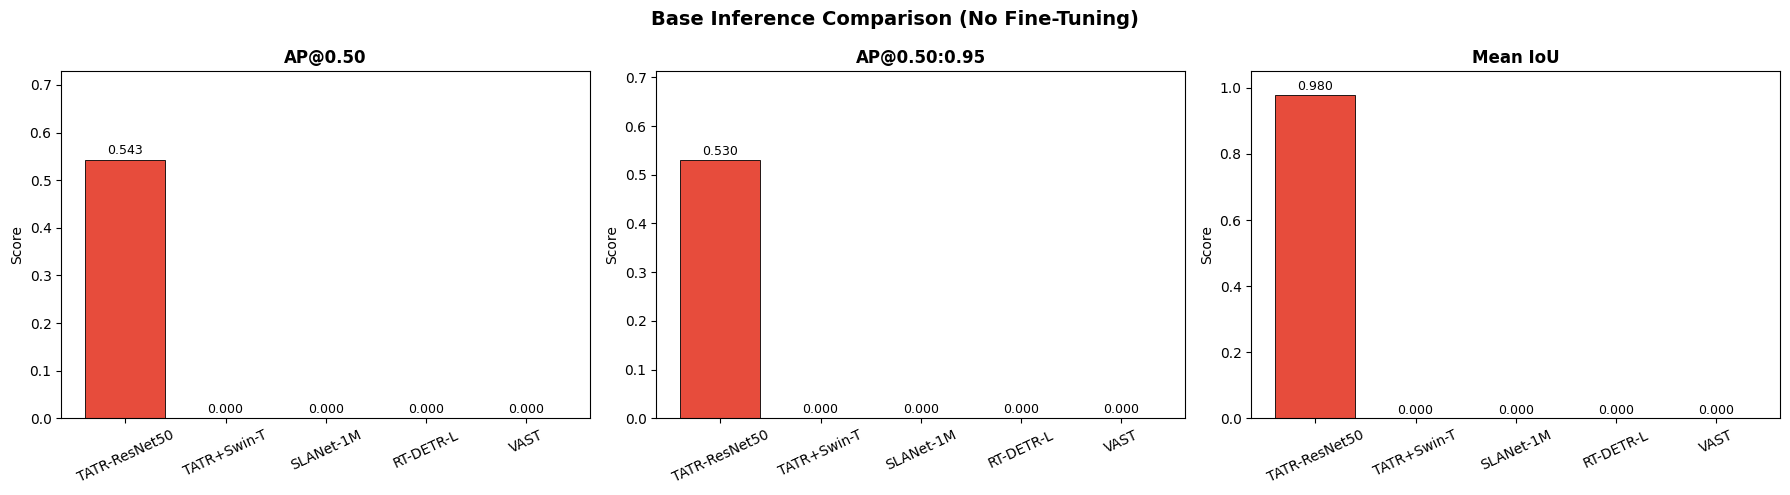

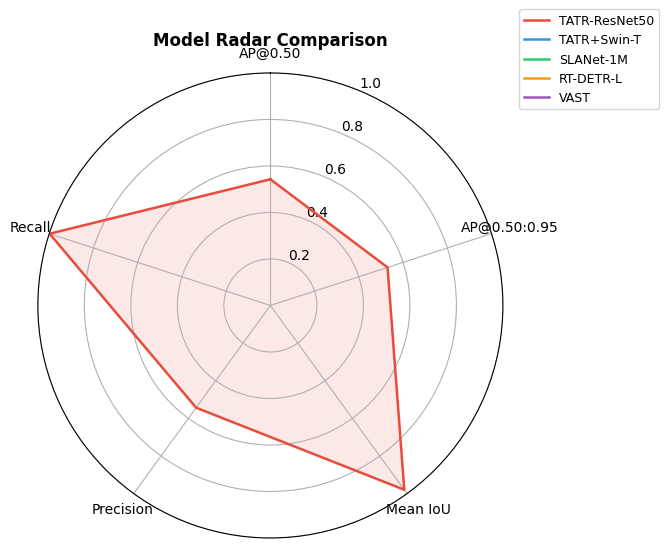

Charts saved: comparison_bars.png, comparison_radar.png


In [ ]:
import math

# ─────────────────────────────────────────────────────────────────────────────
# 13a — Styled comparison table
# ─────────────────────────────────────────────────────────────────────────────
df_sorted = df_metrics.sort_values("AP@0.50", ascending=False)

styled = (
    df_sorted.style
    .background_gradient(cmap="RdYlGn", subset=["AP@0.50", "AP@0.50:0.95", "Mean IoU"])
    .background_gradient(cmap="Blues",  subset=["Precision", "Recall"])
    .format("{:.4f}")
    .set_caption("Base Inference Performance — No Fine-Tuning  (↑ = higher is better)")
)
display(styled)

# Best model per metric
print("\nBest model per metric:")
if not df_metrics.empty:
    for col in df_metrics.columns:
        best = df_metrics[col].idxmax()
        val  = df_metrics.loc[best, col]
        print(f"  {col:<18s}: {best}  ({val:.4f})")
else:
    print("  No metrics available.")

# ─────────────────────────────────────────────────────────────────────────────
# 13b — Grouped bar chart: AP@0.50 / AP@0.50:0.95 / Mean IoU
# ─────────────────────────────────────────────────────────────────────────────
if df_sorted.empty:
    print("No metrics to display.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Base Inference Comparison (No Fine-Tuning)", fontsize=14, fontweight="bold")

    metric_cols  = ["AP@0.50", "AP@0.50:0.95", "Mean IoU"]
    bar_colours  = [MODEL_COLORS.get(m, "#888") for m in df_sorted.index]

    for ax, col in zip(axes, metric_cols):
        vals  = df_sorted[col].values
        bars  = ax.bar(df_sorted.index, vals, color=bar_colours, edgecolor="black", linewidth=0.6)
        ax.set_title(col, fontsize=12, fontweight="bold")
        ax.set_ylim(0, min(1.05, max(vals) * 1.25 + 0.05) if len(vals) > 0 else 1.05)
        ax.set_ylabel("Score")
        ax.tick_params(axis="x", rotation=25)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig("comparison_bars.png", bbox_inches="tight", dpi=150)
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 13c — Radar / Spider chart: Precision / Recall / AP@0.50 / Mean IoU
# ─────────────────────────────────────────────────────────────────────────────
if not df_sorted.empty:
    radar_cols   = ["AP@0.50", "AP@0.50:0.95", "Mean IoU", "Precision", "Recall"]
    N            = len(radar_cols)
    angles       = [n / float(N) * 2 * math.pi for n in range(N)] + [0]   # close polygon

    fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax_r.set_theta_offset(math.pi / 2)
    ax_r.set_theta_direction(-1)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(radar_cols, fontsize=10)
    ax_r.set_ylim(0, 1)

    for model_name in df_metrics.index:
        values = df_metrics.loc[model_name, radar_cols].values.tolist() + \
                 [df_metrics.loc[model_name, radar_cols].values[0]]
        colour = MODEL_COLORS.get(model_name, "#888")
        ax_r.plot(angles, values, color=colour, linewidth=1.8, label=model_name)
        ax_r.fill(angles, values, color=colour, alpha=0.12)

    ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax_r.set_title("Model Radar Comparison", fontsize=12, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig("comparison_radar.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Charts saved: comparison_bars.png, comparison_radar.png")


## Section 14 — Visual Results on Sample Images

For each of the 3 sampled images:  
- **Green boxes** = ground-truth annotations  
- **Coloured boxes** (model-specific) = predicted bounding boxes with confidence score  
- Each row is one image; each column is one model (5 columns total)

The figure is also saved to `comparison_output.png`.

In [ ]:
import random

random.seed(RANDOM_SEED)
sample_records = random.sample(valid_records, min(N_SAMPLE_IMAGES, len(valid_records)))

# ─────────────────────────────────────────────────────────────────────────────
# Category → colour for GT boxes
# ─────────────────────────────────────────────────────────────────────────────
GT_CAT_COLORS = {
    1: "#27AE60",  # table             → green
    2: "#1ABC9C",  # table column      → teal
    3: "#2980B9",  # table row         → blue
    4: "#8E44AD",  # column header     → purple
    5: "#D35400",  # proj row header   → orange
    6: "#C0392B",  # spanning cell     → red
}

def draw_boxes(ax, boxes_info: list, edge_color: str, linestyle: str = "-",
               label_prefix: str = "", alpha: float = 0.85, lw: float = 1.8):
    """Draw bounding boxes on a matplotlib Axes."""
    for info in boxes_info:
        x1, y1, x2, y2 = info["box_xyxy"]
        w = x2 - x1;  h = y2 - y1
        rect = mpatches.Rectangle(
            (x1, y1), w, h,
            linewidth=lw, edgecolor=edge_color,
            facecolor="none", linestyle=linestyle, alpha=alpha,
        )
        ax.add_patch(rect)
        label = info.get("label_text", "")
        if label:
            ax.text(x1, max(y1 - 3, 0), label,
                    color=edge_color, fontsize=5.5,
                    bbox=dict(facecolor="white", alpha=0.55, pad=0.5, edgecolor="none"))


n_rows = len(sample_records)
n_cols = len(MODEL_NAMES)

if n_rows == 0:
    print("No valid records found to display.")
else:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row_idx, rec in enumerate(sample_records):
        img_id   = rec["image_id"]
        img_path = rec["img_path"]
        pil_img  = Image.open(img_path).convert("RGB")
        orig_arr = np.array(pil_img)

        # GT boxes for this image
        gt_info_per_cat = defaultdict(list)
        for ann in ann_by_image.get(img_id, []):
            cat_id = ann["category_id"]
            gt_info_per_cat[cat_id].append({
                "box_xyxy":   coco_xywh_to_xyxy(ann["bbox"]),
                "label_text": CATEGORY_ID_TO_NAME.get(cat_id, str(cat_id)),
            })

        for col_idx, model_name in enumerate(MODEL_NAMES):
            ax = axes[row_idx, col_idx]
            ax.imshow(orig_arr)
            ax.axis("off")

            # Draw GT boxes (green, dashed)
            for cat_id, gt_list in gt_info_per_cat.items():
                draw_boxes(ax, gt_list,
                           edge_color=GT_CAT_COLORS.get(cat_id, "#27AE60"),
                           linestyle="--", label_prefix="GT", lw=1.4, alpha=0.9)

            # Draw predicted boxes (model colour, solid)
            model_preds = all_results[model_name]
            pred_info   = []
            for pred in model_preds.get(img_id, []):
                cat_id = pred["category_id"]
                if cat_id not in CATEGORY_ID_TO_NAME:
                    continue
                lbl = f"{CATEGORY_ID_TO_NAME[cat_id]} {pred['score']:.2f}"
                pred_info.append({
                    "box_xyxy":   pred["box_xyxy"],
                    "label_text": lbl,
                })
            draw_boxes(ax, pred_info,
                       edge_color=MODEL_COLORS.get(model_name, "#E74C3C"),
                       linestyle="-", lw=1.8, alpha=0.95)

            title_suffix = f"({len(pred_info)} pred)" if pred_info else "(no pred)"
            ax.set_title(f"{model_name}\n{title_suffix}", fontsize=8, fontweight="bold")

        # Row label: image filename
        axes[row_idx, 0].set_ylabel(rec["file_name"], fontsize=7, rotation=0,
                                     labelpad=70, va="center")

    # ── Legend ────────────────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(edgecolor=MODEL_COLORS[m], facecolor="none",
                       linestyle="-", linewidth=2, label=m)
        for m in MODEL_NAMES
    ] + [
        mpatches.Patch(edgecolor="#27AE60", facecolor="none",
                       linestyle="--", linewidth=1.5, label="Ground Truth"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=6,
               fontsize=9, bbox_to_anchor=(0.5, -0.02), frameon=True)

    fig.suptitle("Box Predictions vs Ground Truth  (— pred  |  -- GT)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("comparison_output.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Visual comparison saved to: comparison_output.png")


NameError: name 'RANDOM_SEED' is not defined